<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_NLP_Classification_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer


In [2]:
# 1. Завантаження даних
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DATA LOVE/train_class.csv', sep=',')


Mounted at /content/drive


In [3]:
print(df.head())
print(df.info())
print(df.isnull().sum())

df = df.dropna().reset_index(drop=True)
print("Записів після видалення пропусків:", len(df))

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


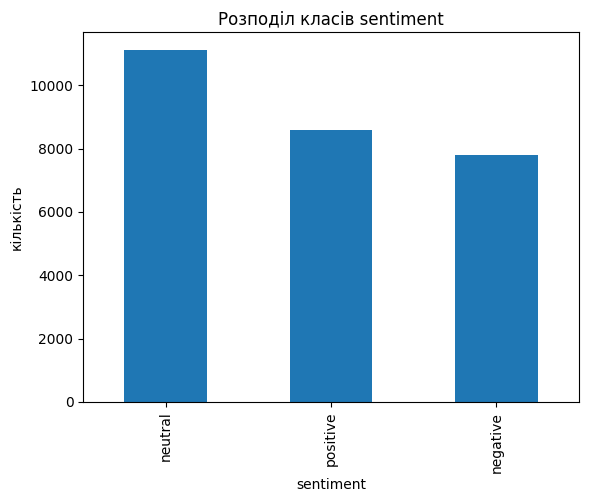

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_len, dtype: float64


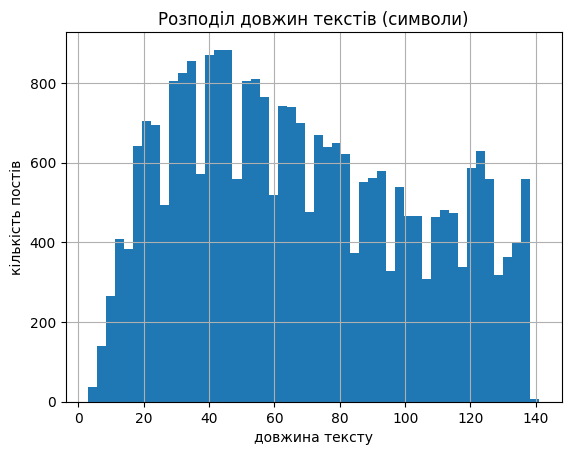

In [4]:
# Розподіл класів
print(df["sentiment"].value_counts())
df["sentiment"].value_counts().plot(kind="bar", title="Розподіл класів sentiment")
plt.xlabel("sentiment")
plt.ylabel("кількість")
plt.show()

# Довжина текстів у символах
df["text_len"] = df["text"].str.len()
print(df["text_len"].describe())

df["text_len"].hist(bins=50)
plt.title("Розподіл довжин текстів (символи)")
plt.xlabel("довжина тексту")
plt.ylabel("кількість постів")
plt.show()

Класи: neutral (11 117) домінує, потім positive (8 582), negative (7 781) — дисбаланс помірний, приблизно 40% / 31% / 28%.

Довжина текстів: медіана 64 символи, середнє 68, IQR від 39 до 97, максимум 141 (типове обмеження твітів). Розподіл зсунутий вправо (right-skewed) — більшість постів короткі-середні (30–100 символів), з довгим хвостом ближче до максимуму.

Висновок: більшість постів короткі-середні (у діапазоні ~30–100 символів), гістограма зазвичай показує пік у районі 20–60 символів і спад до довшого хвоста ближче до 140 (максимум для твітів). Тобто типовий піст — це коротке повідомлення, а не розгорнутий текст.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [5]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

                                                text  \
0                I`d have responded, if I were going   
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview! leave me alone   
4   Sons of ****, why couldn`t they put them on t...   

                      text_clean  
0                     respond go  
1        sooo sad miss san diego  
2                     boss bulli  
3            interview leav alon  
4  son put releas alreadi bought  
Розмір повного словника: 18528
      word  freq
0      day  2497
1       go  2384
2      get  1917
3     good  1600
4     work  1530
5     love  1486
6     like  1462
7      got  1261
8    today  1155
9     time  1104
10     one  1077
11     lol  1029
12   happi  1014
13    want   991
14   thank   990
15    know   980
16    miss   967
17    back   920
18  realli   916
19     see   905


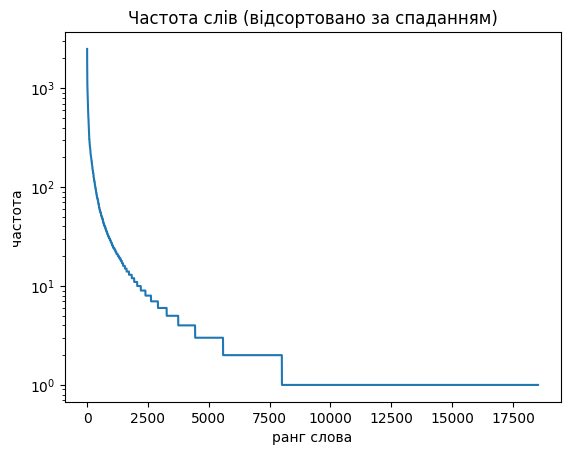

Обрана кількість слів у словнику (freq >= 3): 5584
Розмір матриці BoW: (27480, 5584)


In [6]:
stop_words = set(stopwords.words("english"))
stemmer = SnowballStemmer("english")


def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      # видалення URL
    text = re.sub(r"@\w+", " ", text)                 # видалення згадок @user
    text = re.sub(r"[^a-z\s]", " ", text)              # залишаємо тільки літери
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)


df["text_clean"] = df["text"].apply(preprocess)
print(df[["text", "text_clean"]].head())

# Аналіз: скільки унікальних слів дає словник без обмеження max_features
vectorizer_full = CountVectorizer()
vectorizer_full.fit(df["text_clean"])
print("Розмір повного словника:", len(vectorizer_full.vocabulary_))

# Аналіз частоти слів, щоб обрати max_features
word_freq = vectorizer_full.transform(df["text_clean"]).sum(axis=0).A1
freq_df = pd.DataFrame({"word": vectorizer_full.get_feature_names_out(), "freq": word_freq})
freq_df = freq_df.sort_values("freq", ascending=False).reset_index(drop=True)
print(freq_df.head(20))

freq_df["freq"].plot()
plt.title("Частота слів (відсортовано за спаданням)")
plt.xlabel("ранг слова")
plt.ylabel("частота")
plt.yscale("log")
plt.show()

# Обираємо розмір словника: слова, що зустрічаються хоча б 3 рази
MAX_FEATURES = (freq_df["freq"] >= 3).sum()
print("Обрана кількість слів у словнику (freq >= 3):", MAX_FEATURES)

vectorizer_bow = CountVectorizer(max_features=MAX_FEATURES)
X_bow = vectorizer_bow.fit_transform(df["text_clean"])
print("Розмір матриці BoW:", X_bow.shape)

Повний словник: 18 528 унікальних токенів після очистки/стеммінгу.
Топ-слова: day, go, get, good, work, love, like... Це очікувана для твітів, побутова лексика, емоційно нейтральна чи слабко забарвлена.
Обраний поріг (freq ≥ 3) дав словник 5 584 слова, що прибрало ~13k рідкісних/унікальних токенів (одноразові згадки, помилки друку, специфічні імена).
Матриця BoW: (27480, 5584).

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [7]:
y = df["sentiment"].values

# Розбиття індексів на train/test (80/20)
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

X_train_bow, X_test_bow = X_bow[idx_train], X_bow[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print("Train shape:", X_train_bow.shape, " Test shape:", X_test_bow.shape)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    y_pred = model.predict(X_test_bow)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n=== {name} (accuracy = {acc:.4f}) ===")
    print(classification_report(y_test, y_pred))

best_name = max(results, key=results.get)
print(f"\nНайкраща модель: {best_name} (accuracy = {results[best_name]:.4f})")

best_model = models[best_name]
y_pred_best = best_model.predict(X_test_bow)
print("Матриця плутанини:")
print(confusion_matrix(y_test, y_pred_best, labels=sorted(set(y))))
print("Класи (порядок в матриці):", sorted(set(y)))

Train shape: (21984, 5584)  Test shape: (5496, 5584)

=== Logistic Regression (accuracy = 0.6878) ===
              precision    recall  f1-score   support

    negative       0.70      0.63      0.66      1556
     neutral       0.63      0.72      0.67      2223
    positive       0.77      0.71      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496


=== Decision Tree (accuracy = 0.6359) ===
              precision    recall  f1-score   support

    negative       0.60      0.62      0.61      1556
     neutral       0.63      0.59      0.61      2223
    positive       0.68      0.71      0.69      1717

    accuracy                           0.64      5496
   macro avg       0.64      0.64      0.64      5496
weighted avg       0.64      0.64      0.64      5496


=== Gradient Boosting (accuracy = 0.6636) ===
              precision    recall  f1-score   

Порівняння моделей:
Logistic Regression	0.688	найкраща за accuracy та збалансована за f1 по класах
Decision Tree	0.636	найгірша — типово для одного дерева на розріджених текстових ознаках, схильне до перенавчання
Gradient Boosting	0.664	висока precision, але низький recall на negative (0.45) — модель обережна, пропускає багато негативу

Матриця плутанини (Logistic Regression):
Найбільше плутанини — між neutral і negative (496 negative класифіковано як neutral) та між neutral і positive (428 positive → neutral). Це логічно, бо нейтральні твіти найчастіше "розмиті" за емоційним забарвленням і межують і з позитивом, і з негативом. Positive та negative майже не плутаються напряму (85 і 77 випадків) — модель добре відрізняє полярні емоції, проблема саме в середньому класі.

Оцінка якості помірна, але не висока. Плюси: значно краще за випадкове вгадування (33%) і за наївний baseline "завжди найчастіший клас" (~40%, neutral). Precision/recall на positive і negative пристойні (0.70–0.77).
Мінуси: accuracy ~69% для сентимент-аналізу — середній результат. Головна проблема — клас neutral, який модель або надто часто вибирає (LogReg), або, навпаки, боїться пропустити (Gradient Boosting завищує recall neutral за рахунок negative). Bag-of-words не враховує порядок слів, заперечення ("not good"), контекст — це природна межа підходу.

Висновок: результат прийнятний для baseline / PoC, але для продакшн-рішення варто спробувати TF-IDF або складніші моделі (embeddings, трансформери).

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [8]:
# Модель Logistic Regression, навчена в Завданні 4 (models["Logistic Regression"])
log_reg = models["Logistic Regression"]
feature_names = np.array(vectorizer_bow.get_feature_names_out())

for i, cls in enumerate(log_reg.classes_):
    coefs = log_reg.coef_[i]
    top_pos_idx = np.argsort(coefs)[-15:][::-1]   # слова, що найбільше "тягнуть" у цей клас
    top_neg_idx = np.argsort(coefs)[:15]           # слова, що найбільше "відштовхують" від цього класу

    print(f"\n=== Клас: {cls} ===")
    print("Топ-15 слів ЗА клас (найбільший позитивний вплив):")
    for idx in top_pos_idx:
        print(f"  {feature_names[idx]:15s}  {coefs[idx]:.3f}")

    print("Топ-15 слів ПРОТИ класу (найбільший негативний вплив):")
    for idx in top_neg_idx:
        print(f"  {feature_names[idx]:15s}  {coefs[idx]:.3f}")


=== Клас: negative ===
Топ-15 слів ЗА клас (найбільший позитивний вплив):
  sad              2.666
  suck             2.513
  sorri            2.432
  bore             2.403
  hate             2.317
  fail             2.114
  stupid           2.113
  miss             2.091
  worst            2.048
  exhaust          1.972
  unfortun         1.966
  wors             1.963
  shame            1.941
  terribl          1.928
  horribl          1.910
Топ-15 слів ПРОТИ класу (найбільший негативний вплив):
  glad             -2.355
  awesom           -2.320
  love             -2.128
  beauti           -1.982
  thank            -1.871
  cute             -1.866
  welcom           -1.752
  amaz             -1.581
  enjoy            -1.560
  great            -1.525
  nice             -1.510
  congrat          -1.464
  yum              -1.455
  fine             -1.450
  hope             -1.440

=== Клас: neutral ===
Топ-15 слів ЗА клас (найбільший позитивний вплив):
  indoor           1.638
  chan

Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [10]:
# Той самий препроцесинг (df["text_clean"]) і той самий розмір словника, що і в BoW
vectorizer_tfidf = TfidfVectorizer(max_features=MAX_FEATURES)
X_tfidf = vectorizer_tfidf.fit_transform(df["text_clean"])
print("Розмір матриці TF-IDF:", X_tfidf.shape)

# Використовуємо ті самі індекси idx_train / idx_test з Завдання 4
X_train_tfidf, X_test_tfidf = X_tfidf[idx_train], X_tfidf[idx_test]
# y_train, y_test - ті самі, що і раніше

log_reg_tfidf = LogisticRegression(max_iter=1000)
log_reg_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = log_reg_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"\nLogistic Regression + TF-IDF (accuracy = {acc_tfidf:.4f})")
print(classification_report(y_test, y_pred_tfidf))

print(f"Порівняння: BoW accuracy = {results['Logistic Regression']:.4f}  vs  TF-IDF accuracy = {acc_tfidf:.4f}")

# Аналіз важливості слів для TF-IDF
feature_names_tfidf = np.array(vectorizer_tfidf.get_feature_names_out())
for i, cls in enumerate(log_reg_tfidf.classes_):
    coefs = log_reg_tfidf.coef_[i]
    top_pos_idx = np.argsort(coefs)[-15:][::-1]
    print(f"\nКлас: {cls} (TF-IDF) — топ-15 слів ЗА клас")
    for idx in top_pos_idx:
        print(f"  {feature_names_tfidf[idx]:15s}  {coefs[idx]:.3f}")

Розмір матриці TF-IDF: (27480, 5584)

Logistic Regression + TF-IDF (accuracy = 0.6860)
              precision    recall  f1-score   support

    negative       0.72      0.60      0.65      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.78      0.68      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496

Порівняння: BoW accuracy = 0.6878  vs  TF-IDF accuracy = 0.6860

Клас: negative (TF-IDF) — топ-15 слів ЗА клас
  sad              5.219
  miss             4.852
  sorri            4.623
  hate             4.367
  suck             4.343
  bore             3.952
  fail             3.671
  hurt             3.489
  stupid           3.412
  poor             3.345
  sick             3.268
  tire             3.202
  bad              3.075
  headach          2.911
  ugh              2.711

Клас: neutral (TF-IDF) — топ-15 слів ЗА клас


Порівняння BoW vs TF-IDF:

Векторизація	Accuracy	Negative recall	Neutral recall	Positive recall
BoW	0.6878	0.63	0.72	0.71
TF-IDF	0.6860	0.60	0.75	0.68
Якість практично не змінилася, різниця в accuracy незначна (0.0018, менше похибки округлення на такому test set). Змінився лише баланс: TF-IDF трохи краще ловить neutral за рахунок гіршого negative/positive.

Топ-слова: набір і порядок токенів майже ідентичний BoW (sad, miss, sorri, hate, suck → negative; love, thank, awesom, great, happi → positive). Значення коефіцієнтів більші за масштабом (TF-IDF-ознаки дрібні дробові, тому вага компенсує це), але змістовно — той самий словник впливовості. Клас neutral так само тримається на "шумових" специфічних токенах (indoor, guitar, moro, sp, chan), а не на власних змістовних маркерах — той самий патерн, що і в BoW.

Висновок:

На цьому конкретному датасеті (короткі однорідні твіти) різниця між BoW і TF-IDF виявилась мінімальною, TF-IDF найбільше дає перевагу на текстах різної довжини і з ширшим словником, де важливо знижувати вагу занадто загальних слів. Тут же тексти короткі й приблизно однакової довжини, тож ефект нормалізації майже не проявляється. Але краще, мабуть, обрати TF-IDF для фінальної імплементації. Якість не гірша (практично рівна BoW), підхід автоматично занижує вагу частих малоінформативних слів і підсилює рідкісні дискримінативні, що краще узагальнюється на нових/невидимих даних поза цим конкретним датасетом.
У продакшн-сценарії, де тексти можуть бути різної довжини, ця перевага стане більш вираженою, ніж тут.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [12]:
# Формуємо DataFrame з тестовими текстами, істинними і передбаченими мітками
test_df = df.iloc[idx_test].copy()
test_df["y_true"] = y_test
test_df["y_pred"] = y_pred_tfidf

errors = test_df[test_df["y_true"] != test_df["y_pred"]]
print("Кількість помилок:", len(errors), "з", len(test_df), f"({len(errors)/len(test_df):.1%})")

# Розподіл помилок по парах (справжній клас -> передбачений)
print("\nНайчастіші пари помилок (true -> pred):")
print(errors.groupby(["y_true", "y_pred"]).size().sort_values(ascending=False))

# Приклади помилок для кожної пари класів
for true_cls in ["negative", "neutral", "positive"]:
    for pred_cls in ["negative", "neutral", "positive"]:
        if true_cls == pred_cls:
            continue
        subset = errors[(errors["y_true"] == true_cls) & (errors["y_pred"] == pred_cls)]
        if len(subset) > 0:
            print(f"\ntrue={true_cls}, pred={pred_cls} (приклади)")
            print(subset[["text", "y_true", "y_pred"]].head(3).to_string(index=False))

# Довжина тексту: чи довші/коротші тексти частіше помиляються?
test_df["text_len"] = test_df["text"].str.len()
correct_len = test_df[test_df["y_true"] == test_df["y_pred"]]["text_len"].mean()
errors_len_mean = test_df.loc[errors.index, "text_len"].mean()
print(f"\nСередня довжина тексту: правильно класифіковані = {correct_len:.1f}, помилки = {errors_len_mean:.1f}")

Кількість помилок: 1726 з 5496 (31.4%)

Найчастіші пари помилок (true -> pred):
y_true    y_pred  
negative  neutral     548
positive  neutral     475
neutral   negative    299
          positive    257
negative  positive     81
positive  negative     66
dtype: int64

true=negative, pred=neutral (приклади)
                                                                                                       text   y_true  y_pred
                                            Reading and taking notes but undertanding none of it  ... HELP! negative neutral
                   2 hours after teleconference. but can`t go back to sleep. got some work to do. sigh sigh negative neutral
Youtube isn`t working...and I wanted to watch Britains Got Talent.  I`m debating about having a pity party. negative neutral

true=negative, pred=positive (приклади)
                                                                                                  text   y_true   y_pred
                              

Аналіз помилок:

31,4% помилок, і, як і очікувалося з матриці плутанини раніше, основна маса — це плутанина з neutral (548+475+299+257 = майже вся помилка), а прямі помилки negative↔positive рідкісні (81+66).

Типові патерни помилок:
Змішані/суперечливі сигнали в одному тексті — "not ideal... but perfect for a lazy day" (negative→positive): є і негативне, і позитивне слово одночасно, модель BoW/TF-IDF просто підсумовує ваги і "перемагає" не той сигнал.
Сарказм і непряма мова — "Should be a good show... at least I'm hoping so" (neutral→positive), "friday night is my fav night... but now stupid dog training" (positive→negative) — формальні позитивні/негативні слова присутні, але справжній тон речення інший або нейтральніший, ніж підказують окремі слова.
Емоція виражена без "словникових" маркерів — "HELP!", "sigh sigh", "Owww", "Wrong... LOL" — не входять у топ-впливові слова моделі, тому емоційний сигнал втрачається повністю.
Питання й нейтральні формулювання з одним емоційним словом — "yum. Do you do home delivery" (positive→neutral) — один позитивний токен губиться на фоні нейтрального питання.
Довші тексти помиляються частіше (76.3 vs 64.5 символів) — підтверджує гіпотезу про змішані сигнали: що більше слів, то вища ймовірність зустріти суперечливі за тоном токени.

3 шляхи покращення:

N-грами та обробка заперечень — щоб модель бачила словосполучення, а не лише окремі слова (наприклад "wish I could help" — увесь зворот, а не "help" окремо).
Контекстні моделі (трансформери) для випадків сарказму ("Should be a good show... at least I'm hoping") і неявного вираження емоції через структуру речення, а не окремі слова.
Спеціальна робота з класом neutral: ансамбль "емоційний vs нейтральний" + "позитив vs негатив", class_weight або перегляд межових анотацій, оскільки саме тут зосереджена переважна більшість помилок.

Це логічне завершення циклу: BoW/TF-IDF дали приблизно однакову й помірну якість (~69%), а аналіз помилок показує, що межа підходу не у виборі векторизатора, а у самій природі методу мішка слів, який не бачить контексту, порядку слів і тону речення.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model